# Data Analysis for Option 1 Results

In [201]:
import pandas as pd

df = pd.read_csv("../references/four_print_results/quick_results(testes)0-7.csv")
df.head()

,param_hybrid_weights,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc
0,"[0, 5, 1, 5]",0.638068,0.656389,0.738333,0.692825
1,"[0, 6, 1, 6]",0.624928,0.640486,0.738667,0.689587
2,"[0, 7, 1, 7]",0.629372,0.643308,0.747000,0.688119
3,"[3, 1, 7, 6]",0.625024,0.644176,0.722000,0.687810
4,"[2, 0, 2, 7]",0.634106,0.654729,0.714333,0.685254


In [202]:
#Weights saved as a string for the CSV, so we will fix this 
df["param_hybrid_weights"] = [ [int(df["param_hybrid_weights"][i][1]), int(df["param_hybrid_weights"][i][4]), int(df["param_hybrid_weights"][i][7]), int(df["param_hybrid_weights"][i][10])] for i in range(0, len(df["param_hybrid_weights"]))]
df.head()

,param_hybrid_weights,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc
0,"[0, 5, 1, 5]",0.638068,0.656389,0.738333,0.692825
1,"[0, 6, 1, 6]",0.624928,0.640486,0.738667,0.689587
2,"[0, 7, 1, 7]",0.629372,0.643308,0.747000,0.688119
3,"[3, 1, 7, 6]",0.625024,0.644176,0.722000,0.687810
4,"[2, 0, 2, 7]",0.634106,0.654729,0.714333,0.685254


In [203]:
#Calculate percentage contributions from the weights, as these are often more intuitive
morgan_weight = [df["param_hybrid_weights"][i][1] for i in range(0,len(df["param_hybrid_weights"]))]
toxprint_weight = [df["param_hybrid_weights"][i][0] for i in range(0,len(df["param_hybrid_weights"]))]
torsion_weight = [df["param_hybrid_weights"][i][2] for i in range(0,len(df["param_hybrid_weights"]))]
toxcast_weight = [df["param_hybrid_weights"][i][3] for i in range(0,len(df["param_hybrid_weights"]))]

df["morgan"] = [morgan_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(morgan_weight))]
df["toxprint"] = [toxprint_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(toxprint_weight))]
df["torsion"] = [torsion_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(torsion_weight))]
df["toxcast"] = [toxcast_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(toxcast_weight))]

In [204]:
df = df.sort_values("mean_test_accuracy", ascending = False).drop(columns = {"param_hybrid_weights"})

In [205]:
df.head()

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast
230,0.651401,0.671560,0.721667,0.661913,0.285714,0.000000,0.214286,0.500000
224,0.642512,0.663054,0.721667,0.662048,0.300000,0.000000,0.200000,0.500000
645,0.638647,0.665489,0.689667,0.652508,0.000000,0.083333,0.333333,0.583333
276,0.638551,0.667993,0.673000,0.660405,0.000000,0.076923,0.384615,0.538462
249,0.638357,0.668822,0.689333,0.661071,0.000000,0.111111,0.333333,0.555556


## Top/Bottom DataFrames
 There are many, many results for this data set, so let's look only at the best and worst in each category to examine patterns as well. 

In [214]:
accuracy_df1 = df.sort_values("mean_test_accuracy").iloc[0:10, :]
accuracy_df2 = df.sort_values("mean_test_accuracy").iloc[-10:, :]
accuracy_df3 = df.sort_values("mean_test_accuracy").iloc[1870:1880, :]
accuracy_df = pd.concat([accuracy_df1, accuracy_df2, accuracy_df3]).sort_values("mean_test_accuracy")
accuracy_df.head(10)

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast
331,0.637971,0.665954,0.688333,0.658802,0.333333,0.000000,0.083333,0.583333
181,0.637971,0.671510,0.680333,0.663706,0.300000,0.000000,0.100000,0.600000
323,0.638068,0.666782,0.688667,0.659040,0.285714,0.000000,0.142857,0.571429
0,0.638068,0.656389,0.738333,0.692825,0.454545,0.000000,0.090909,0.454545
432,0.638261,0.665305,0.714333,0.656460,0.200000,0.066667,0.266667,0.466667
249,0.638357,0.668822,0.689333,0.661071,0.000000,0.111111,0.333333,0.555556
276,0.638551,0.667993,0.673000,0.660405,0.000000,0.076923,0.384615,0.538462
645,0.638647,0.665489,0.689667,0.652508,0.000000,0.083333,0.333333,0.583333
224,0.642512,0.663054,0.721667,0.662048,0.300000,0.000000,0.200000,0.500000
230,0.651401,0.671560,0.721667,0.661913,0.285714,0.000000,0.214286,0.500000


In [193]:
precision_df1 = df.sort_values("mean_test_precision").iloc[0:10, :]
precision_df2 = df.sort_values("mean_test_precision").iloc[-10:, :]
precision_df = pd.concat([precision_df1, precision_df2])
precision_df.tail()

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast
276,0.638551,0.667993,0.673000,0.660405,0.000000,0.076923,0.384615,0.538462
249,0.638357,0.668822,0.689333,0.661071,0.000000,0.111111,0.333333,0.555556
181,0.637971,0.671510,0.680333,0.663706,0.300000,0.000000,0.100000,0.600000
230,0.651401,0.671560,0.721667,0.661913,0.285714,0.000000,0.214286,0.500000
345,0.633913,0.672929,0.673000,0.658444,0.000000,0.090909,0.363636,0.545455


In [199]:
recall_df1 = df.sort_values("mean_test_recall").iloc[0:10, :]
recall_df2 = df.sort_values("mean_test_recall").iloc[-10:, :]
recall_df = pd.concat([recall_df1, recall_df2])
recall_df.tail()

,param_hybrid_weights,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc
2019,"[1, 6, 6, 1]",0.629469,0.623377,0.820333,0.630587
414,"[1, 5, 1, 1]",0.616425,0.616884,0.822000,0.656849
1338,"[2, 7, 1, 2]",0.620676,0.624949,0.822000,0.641341
750,"[2, 7, 1, 1]",0.625121,0.627688,0.830333,0.650413
1194,"[2, 6, 1, 1]",0.625121,0.627688,0.830333,0.643500


In [176]:
roc_df1 = df.sort_values("mean_test_roc_auc").iloc[0:10, :]
roc_df2 = df.sort_values("mean_test_roc_auc").iloc[-10:, :]
roc_df = pd.concat([roc_df1, roc_df2])
roc_df.tail()

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast
4,0.634106,0.654729,0.714333,0.685254,0.000000,0.181818,0.181818,0.636364
3,0.625024,0.644176,0.722000,0.687810,0.058824,0.176471,0.411765,0.352941
2,0.629372,0.643308,0.747000,0.688119,0.466667,0.000000,0.066667,0.466667
1,0.624928,0.640486,0.738667,0.689587,0.461538,0.000000,0.076923,0.461538
0,0.638068,0.656389,0.738333,0.692825,0.454545,0.000000,0.090909,0.454545


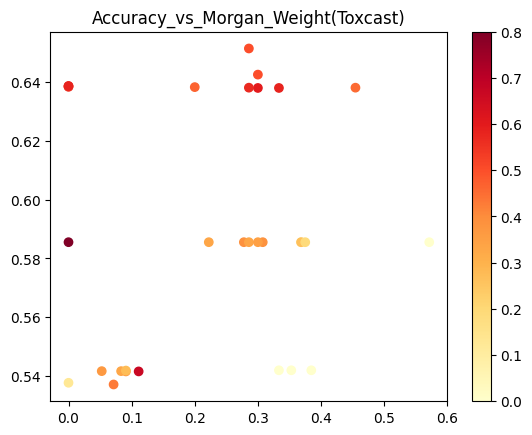

In [207]:
import matplotlib.pyplot as plt

#View and save results as scatterplot to analyze for trends. Note that most relations do not 
# appear to be linear, so such a regression may not be the best choice

#Accuracy
plt.scatter(x = accuracy_df["morgan"], y= accuracy_df["mean_test_accuracy"], c= accuracy_df["toxcast"], cmap = "YlOrRd")
plt.colorbar()
title = "Accuracy_vs_Morgan_Weight(Toxcast)"
plt.title(title)
# plt.savefig(f"../references/four_print_results/{title}_scatter.png")
plt.show()

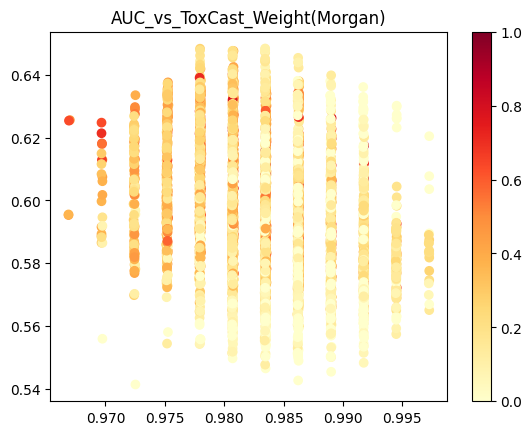

In [186]:
#ROC_AUC
plt.scatter(x = df["mean_test_recall"], y=df["mean_test_roc_auc"], c= df["morgan"], cmap = "YlOrRd")
plt.colorbar()
title = "AUC_vs_ToxCast_Weight(Morgan)"
plt.title(title)
# plt.savefig(f"../references/four_print_results/{title}_scatter.png")
plt.show()

# Data Analysis for Long-Form Results

In [17]:
import pandas as pd

score_df = pd.read_csv("../references/tp_tor_mor/prelim_results+tc_df.csv")
score_df["weights"] = [ [int(score_df["weights"][i][1]), int(score_df["weights"][i][4]), int(score_df["weights"][i][7]), int(score_df["weights"][i][10])] for i in range(0, len(score_df["weights"]))]
score_df.head()

,weights,TP,TN,FP,FN,accuracy,precision,recall
0,"[0, 0, 0, 1]",336,18,88,26,0.756410,0.792453,0.928177
1,"[0, 0, 1, 0]",331,17,89,31,0.743590,0.788095,0.914365
2,"[0, 0, 1, 1]",336,13,93,26,0.745726,0.783217,0.928177
3,"[0, 0, 1, 2]",339,12,94,23,0.750000,0.782910,0.936464
4,"[0, 0, 2, 1]",335,14,92,27,0.745726,0.784543,0.925414


In [32]:
#Calculate percentage contributions from the weights, as these are often more intuitive
morgan_weight = [score_df["weights"][i][1] for i in range(0,len(score_df["weights"]))]
toxprint_weight = [score_df["weights"][i][0] for i in range(0,len(score_df["weights"]))]
torsion_weight = [score_df["weights"][i][2] for i in range(0,len(score_df["weights"]))]
toxcast_weight = [score_df["weights"][i][3] for i in range(0,len(score_df["weights"]))]

score_df["morgan"] = [morgan_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(morgan_weight))]
score_df["toxprint"] = [toxprint_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(toxprint_weight))]
score_df["torsion"] = [torsion_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(torsion_weight))]
score_df["toxcast"] = [toxcast_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(toxcast_weight))]

In [33]:
#Check the DataFrame
score_df.head()

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
0,"[0, 0, 0, 1]",336,18,88,26,0.756410,0.792453,0.928177,0.0,0.0,0.000000,1.000000
1,"[0, 0, 1, 0]",331,17,89,31,0.743590,0.788095,0.914365,0.0,0.0,1.000000,0.000000
2,"[0, 0, 1, 1]",336,13,93,26,0.745726,0.783217,0.928177,0.0,0.0,0.500000,0.500000
3,"[0, 0, 1, 2]",339,12,94,23,0.750000,0.782910,0.936464,0.0,0.0,0.333333,0.666667
4,"[0, 0, 2, 1]",335,14,92,27,0.745726,0.784543,0.925414,0.0,0.0,0.666667,0.333333


In [34]:
#Obtain best combination for accuracy
score_df.loc[score_df["accuracy"]==max(score_df["accuracy"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
22,"[1, 0, 1, 0]",344,16,90,18,0.769231,0.792627,0.950276,0.0,0.5,0.5,0.0


In [35]:
#Obtain best combination for precision
score_df.loc[score_df["precision"]==max(score_df["precision"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
50,"[2, 0, 2, 1]",341,17,89,21,0.764957,0.793023,0.941989,0.0,0.4,0.4,0.2


In [36]:
#Obtain best combination for recall
score_df.loc[score_df["recall"]==max(score_df["recall"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
19,"[1, 0, 0, 0]",345,11,95,17,0.760684,0.784091,0.953039,0.0,1.0,0.0,0.0


In [37]:
#Obtain best combination for not getting false positives
score_df.loc[score_df["FP"]==min(score_df["FP"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
0,"[0, 0, 0, 1]",336,18,88,26,0.75641,0.792453,0.928177,0.0,0.0,0.0,1.0
27,"[1, 0, 2, 2]",336,18,88,26,0.75641,0.792453,0.928177,0.0,0.2,0.4,0.4


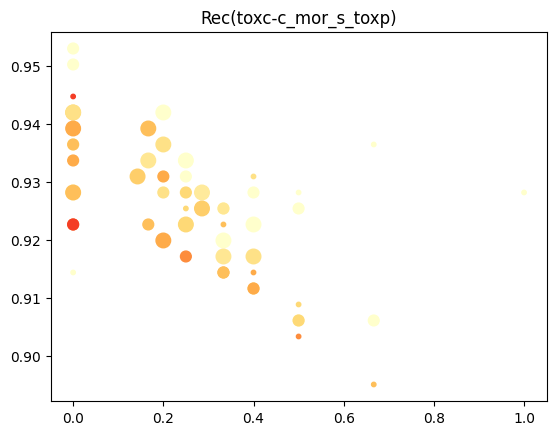

In [38]:
import matplotlib.pyplot as plt

#View and save results as scatterplot to analyze for trends. Note that most relations do not 
# appear to be linear, so such a regression may not be the best choice
plt.scatter(x = score_df["toxcast"], y= score_df["recall"], c= score_df["morgan"], cmap = "YlOrRd", s = [i*50+10 for i in toxprint_weight])
title = "Rec(toxc-c_mor_s_toxp)"
plt.title(title)
# plt.savefig(f"../references/tp_tor_mor/91test{title}percents_scatter.png")
plt.show()